# Cohort comparison — 2015 vs NewData vs PADS

Everything measured across the three cohorts, in one place. Each section is
independent; run section 1 first, then any other.

| cohort | sensors | signal | classes | ET | conditions |
|---|---|---|---|---|---|
| 2015 | 3 (hand / lower_arm / upper_arm) | quaternion → ω | N, PD, ET | 16 | REST, OUT, WING |
| NewData 2025 | 3, both limbs | quaternion → ω | **ET only** | 6 | REST, OUT (+5 unused tasks) |
| PADS | 1 wrist | **raw gyro** | N, PD, ET | 28 | Relaxed, StretchHold |

**Three things the code enforces, each because it went wrong once:**
* PADS labels are re-derived from the manifest by **exact** diagnosis match —
  substring matching put 13 non-ET patients into ET and 21 parkinsonian mimics
  into PD (`reports/pads_label_bug.md`).
* NewData is **segmented** — the raw 38 s free-form exports have only 9.9 % of
  power in the tremor band (`reports/frequency_across_cohorts.md`).
* PD-vs-ET is always **balanced accuracy**; the majority baseline is 0.833
  (2015) and 0.908 (PADS), so raw accuracy is misleading.

## 1. Setup and cohort verification

In [1]:
import sys, os
if os.path.basename(os.getcwd()) == "tfbench": os.chdir("..")
sys.path.insert(0, os.getcwd())
import numpy as np, matplotlib.pyplot as plt, csv, collections
from tfbench.frequency_report import load_cohorts, patient_freqs, _evaluate

COHORTS = load_cohorts("Data")
print(f"{'cohort':>9}{'condition':>14}{'recordings':>12}{'patients':>10}{'N/PD/ET':>14}")
for coh, cond, recs, ch in COHORTS:
    y = np.array([r.y for r in recs])
    pats = {r.subject for r in recs}
    per = [len({r.subject for r in recs if r.y == k}) for k in (0,1,2)]
    print(f"{coh:>9}{cond:>14}{len(recs):>12}{len(pats):>10}{str(per):>14}")

   cohort     condition  recordings  patients       N/PD/ET
     2015          REST         275       152  [61, 75, 16]
     2015           OUT         274       151  [61, 75, 15]
     2015          WING         250       137  [61, 63, 13]
  NewData    REST (seg)          12         6     [0, 0, 6]
  NewData     OUT (seg)          12         6     [0, 0, 6]
     PADS       Relaxed         766       383 [79, 276, 28]
     PADS   StretchHold         766       383 [79, 276, 28]


### 1b. Verify the PADS diagnosis filter

Should print **only** `Healthy`, `Parkinson's`, `Essential Tremor` and give
79 / 276 / 28 patients — the counts published in Varghese et al. 2024. Any
parkinsonian mimic appearing here means the filter has regressed.

In [2]:
MIMIC = ("atypical","hypokinetic","vascular parkinson","lewy","supranuclear",
         "multiple system","spinocerebellar","dystonia","swedd",
         "leukoencephalopathy","unknown etiology","functional")
for folder in ("pads_relaxed", "pads_stretchhold"):
    try:
        rows = list(csv.DictReader(open(f"{folder}/manifest.csv")))
    except FileNotFoundError:
        print(f"{folder}: not present — see docs/EXTRACT_PADS_RELAXED.md"); continue
    diag = collections.Counter(r["raw_label"].strip() for r in rows)
    pats = {(r["patient"], r["class"]) for r in rows}
    per  = collections.Counter(c for _, c in pats)
    bad  = [d for d in diag if any(k in d.lower() for k in MIMIC)]
    print(f"\n{folder}")
    for d, n in sorted(diag.items()): print(f"   {n//2:>3} pts  {d!r}")
    ok = (per['N'], per['PD'], per['ET']) == (79, 276, 28)
    print(f"   -> N={per['N']} PD={per['PD']} ET={per['ET']}  "
          f"{'OK (matches publication)' if ok else '<-- MISMATCH'}")
    if bad: print(f"   !! mimics still present: {bad}")


pads_relaxed
    28 pts  'Essential Tremor'
    79 pts  'Healthy'
   276 pts  "Parkinson's"
   -> N=79 PD=276 ET=28  OK (matches publication)

pads_stretchhold
    28 pts  'Essential Tremor'
    79 pts  'Healthy'
   276 pts  "Parkinson's"
   -> N=79 PD=276 ET=28  OK (matches publication)


## 2. Mean and max frequency

Welch PSD, 3–15 Hz, wrist-equivalent sensor, one value per patient. Identical
path for all cohorts so the comparison is like-for-like.

In [3]:
from tfbench.frequency_report import report
S = report("Data")     # prints tables A (descriptives), B (PD-vs-ET), C (classification)

### A. Median MAX and MEAN frequency (Hz) per class
   cohort    condition                 N                PD                ET
                              max / mean        max / mean        max / mean
     2015         REST       7.03 / 8.13       5.47 / 7.09       6.15 / 7.45


     2015          OUT       7.81 / 8.29       6.64 / 7.35       6.45 / 7.25


     2015         WING       3.71 / 7.15       4.49 / 6.51       5.66 / 6.63


  NewData   REST (seg)                 —                 —       5.86 / 6.59


  NewData    OUT (seg)                 —                 —       6.93 / 7.11


...

     2015         WING     PD-vs-ET    76  0.513  0.829    0.462  0.499   0.213 [0.05,0.37]


     PADS      Relaxed  N-vs-Tremor   383  0.491  0.794    0.468  0.499   0.612 [0.56,0.66]


     PADS      Relaxed     PD-vs-ET   304  0.691  0.908    0.669  0.759   0.277 [0.18,0.38]


     PADS  StretchHold  N-vs-Tremor   383  0.629  0.794    0.612  0.664   0.733 [0.69,0.77]


     PADS  StretchHold     PD-vs-ET   304  0.724  0.908    0.703  0.775   0.311 [0.20,0.41]


### 2b. Distributions — where the cohorts disagree

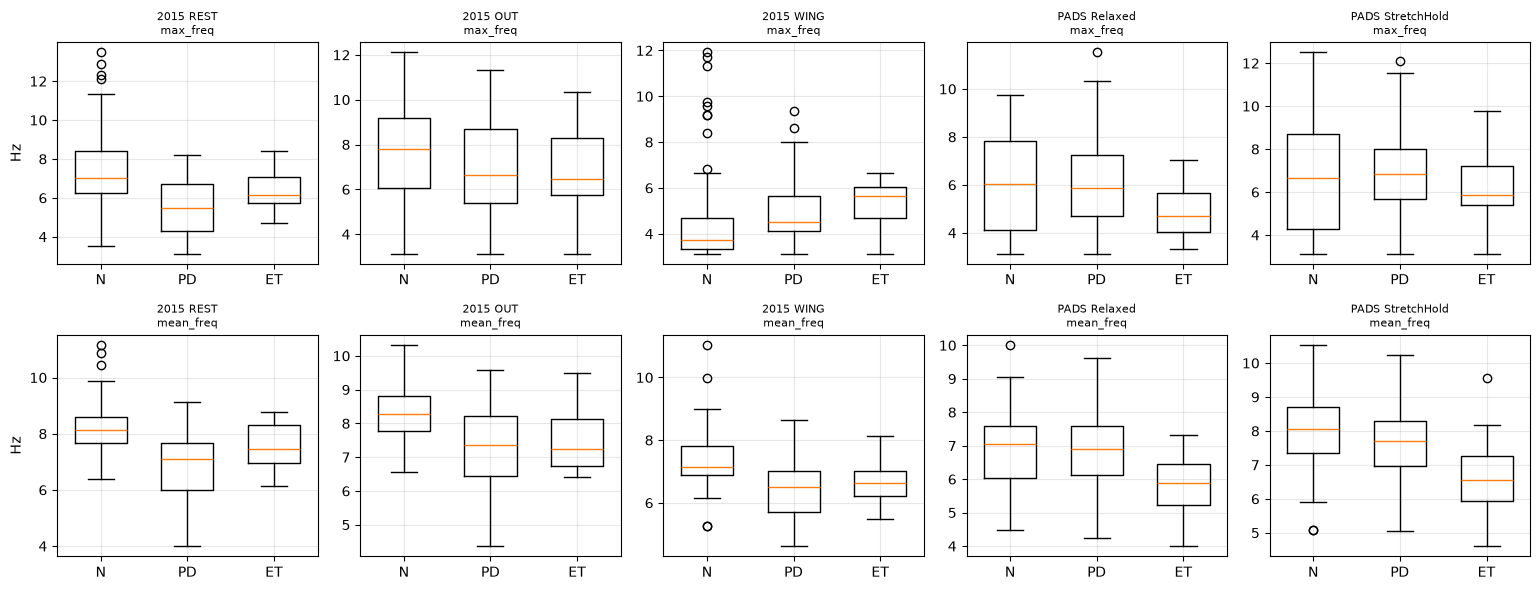

PD - ET median difference (positive = PD faster):
      2015          REST: -0.36 Hz   PD slower
      2015           OUT: +0.11 Hz   PD FASTER
      2015          WING: -0.12 Hz   PD slower
      PADS       Relaxed: +1.01 Hz   PD FASTER
      PADS   StretchHold: +1.16 Hz   PD FASTER


In [4]:
plot_me = [k for k in S if (S[k][1] == 1).sum() >= 3 and (S[k][1] == 2).sum() >= 3]
fig, axes = plt.subplots(2, len(plot_me), figsize=(3.1*len(plot_me), 6), squeeze=False)
for col, key in enumerate(plot_me):
    V, y, g = S[key]
    for row, (j, nm) in enumerate([(0, "max_freq"), (1, "mean_freq")]):
        ax = axes[row][col]
        data = [V[y == k, j] for k in (0, 1, 2) if (y == k).any()]
        labs = [c for k, c in enumerate(["N","PD","ET"]) if (y == k).any()]
        ax.boxplot(data, tick_labels=labs, widths=.6)
        ax.set_title(f"{key[0]} {key[1]}\n{nm}", fontsize=8)
        ax.set_ylabel("Hz" if col == 0 else ""); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("PD - ET median difference (positive = PD faster):")
for key in plot_me:
    V, y, _ = S[key]
    d = np.median(V[y==1,1]) - np.median(V[y==2,1])
    print(f"  {key[0]:>8} {key[1]:>13}: {d:+.2f} Hz   {'PD FASTER' if d>0 else 'PD slower'}")

**The key disagreement.** At rest the two cohorts point in *opposite*
directions, both significantly: 2015 has PD slower than ET (the textbook
picture), PADS has PD faster (p<0.0001). A model trained on one is therefore
anti-predictive on the other — which is exactly what section 4 shows.

## 3. Method × cohort × condition

Does the choice of time-frequency method matter, and does the ranking transfer?
Slow: 12 methods × several cohorts. Trim `METHODS_TRY` for a quick pass.

In [5]:
from tfbench.merged import descriptor_table, loso, bal_acc
METHODS_TRY = ["welch", "cwt", "stft512", "multitaper"]

print(f"{'cohort':>9}{'condition':>14}{'n PD/ET':>10}" + "".join(f"{m:>12}" for m in METHODS_TRY))
grid = {}
for coh, cond, recs, ch in COHORTS:
    y0 = np.array([r.y for r in recs])
    if not ((y0 == 1).any() and (y0 == 2).any()):
        continue                       # ET-only cohort: nothing to discriminate
    row = []
    for m in METHODS_TRY:
        X, y, g = descriptor_table(recs, m, ch)
        k = y != 0; yy = (y[k] == 2).astype(int)
        _, pred = loso(X[k], yy, g[k])
        row.append(bal_acc(yy, pred))
    grid[(coh, cond)] = row
    n0, n1 = int((y[k]==0).sum()), int(yy.sum())
    print(f"{coh:>9}{cond:>14}{f'{n0}/{n1}':>10}" + "".join(f"{v:>12.3f}" for v in row), flush=True)

   cohort     condition   n PD/ET       welch         cwt     stft512  multitaper


     2015          REST      0/16       0.666       0.545       0.730       0.710


     2015           OUT      0/15       0.507       0.547       0.460       0.567


     2015          WING      0/13       0.534       0.409       0.526       0.502


     PADS       Relaxed      0/28       0.675       0.641       0.671       0.689


     PADS   StretchHold      0/28       0.734       0.774       0.749       0.736


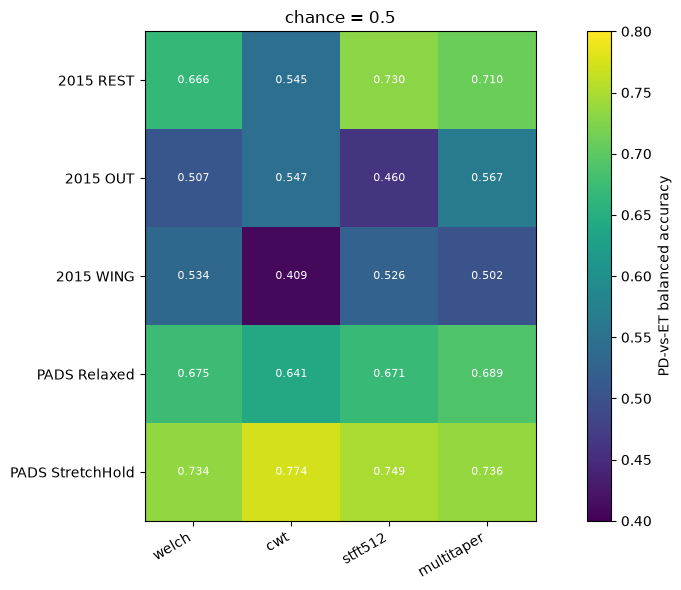

Best method per row — note the ranking does NOT transfer between cohorts:
      2015          REST: stft512  (0.730)
      2015           OUT: multitaper  (0.567)
      2015          WING: welch  (0.534)
      PADS       Relaxed: multitaper  (0.689)
      PADS   StretchHold: cwt  (0.774)


In [6]:
fig, ax = plt.subplots(figsize=(1.6*len(METHODS_TRY)+4, 0.8*len(grid)+2))
M = np.array([grid[k] for k in grid])
im = ax.imshow(M, cmap="viridis", vmin=0.4, vmax=0.8)
fig.colorbar(im, label="PD-vs-ET balanced accuracy")
ax.set_xticks(range(len(METHODS_TRY))); ax.set_xticklabels(METHODS_TRY, rotation=30, ha="right")
ax.set_yticks(range(len(grid))); ax.set_yticklabels([f"{a} {b}" for a,b in grid])
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i,j]:.3f}", ha="center", va="center", color="w", fontsize=8)
ax.axvline(-.5, color='k'); ax.set_title("chance = 0.5")
plt.tight_layout(); plt.show()
print("Best method per row — note the ranking does NOT transfer between cohorts:")
for (a,b), row in grid.items():
    print(f"  {a:>8} {b:>13}: {METHODS_TRY[int(np.argmax(row))]}  ({max(row):.3f})")

## 4. The chosen design — merge 2015 + NewData, validate on PADS

Merged at **REST only**: at OUT the device probe fails, and since NewData is
entirely ET the model could read "new device ⇒ tremor". Probe is judged on
`|AUC − 0.5|`, because an AUC of 0.000 is *maximally* separable (LOO-inverted),
not safe.

In [7]:
from tfbench.merged import merge, report as mreport, external_validate
from tremor.quaternion_data import load_quaternion_recordings
from pdetn.load_2025 import load_2025
from pdetn.crossdataset import load_pads_extracted

loc = load_quaternion_recordings("Data", action="REST", mode="angular_velocity")
new = load_2025(mode="angular_velocity", conditions=("REST",))
ext = {}
for folder, task in (("pads_relaxed","Relaxed"), ("pads_stretchhold","StretchHold")):
    try: ext[task] = load_pads_extracted(folder, task=task)
    except FileNotFoundError: print(f"  {folder} missing — skipping {task}")

for meth in ["welch", "cwt"]:
    (X, y, g), info = merge(loc, new, meth)
    tag = "pass" if info["deviation"] < 0.25 else "CONFOUNDED"
    print(f"\n-- {meth} --  NewData device probe AUC {info['identity_auc']:.3f} "
          f"(|dev| {info['deviation']:.3f}) {tag}")
    k = y != 0
    Xa, ya, ga = X[k], (y[k] == 2).astype(int), g[k]
    pr, pred = loso(Xa, ya, ga)
    mreport(ya, pr, pred, ga, "PD-vs-ET merged LOSO (internal)")
    for task, recs in ext.items():
        Xp, yp, gp = descriptor_table(recs, meth, slice(0,3))
        kp = yp != 0
        external_validate(Xa, ya, Xp[kp], (yp[kp]==2).astype(int), gp[kp],
                          f"PD-vs-ET -> PADS {task} (external)")


-- welch --  NewData device probe AUC 0.698 (|dev| 0.198) pass


               PD-vs-ET merged LOSO (internal) n= 97 pos= 22 | bal-acc 0.740 | AUC 0.770 | F1 0.557 [0.40,0.70] | maj 0.773


           PD-vs-ET -> PADS Relaxed (external) n=304 pos= 28 | bal-acc 0.432 | AUC 0.420 | F1 0.115 [0.05,0.18] | maj 0.908


       PD-vs-ET -> PADS StretchHold (external) n=304 pos= 28 | bal-acc 0.516 | AUC 0.430 | F1 0.147 [0.05,0.25] | maj 0.908



-- cwt --  NewData device probe AUC 0.594 (|dev| 0.094) pass


               PD-vs-ET merged LOSO (internal) n= 97 pos= 22 | bal-acc 0.674 | AUC 0.769 | F1 0.484 [0.32,0.62] | maj 0.773


           PD-vs-ET -> PADS Relaxed (external) n=304 pos= 28 | bal-acc 0.475 | AUC 0.424 | F1 0.119 [0.05,0.20] | maj 0.908


       PD-vs-ET -> PADS StretchHold (external) n=304 pos= 28 | bal-acc 0.494 | AUC 0.448 | F1 0.094 [0.00,0.20] | maj 0.908


**Expected:** internal ≈0.74 for welch, but external AUC **below 0.5** on
both PADS tasks — including `Relaxed`, which is task-matched. That is not noise;
it is the inverted PD/ET direction from section 2b. PD-vs-ET is therefore an
**internal-only** result. N-vs-Tremor is the axis that does transfer
(OUT-trained → PADS StretchHold, ≈0.736 / AUC 0.783).

## 5. What this notebook establishes

1. **2015 and PADS are mirror images.** 2015 detects tremor better
   (N-vs-Tremor up to 0.785 vs PADS 0.612); PADS separates PD from ET better
   (0.703 vs 0.568 on frequency alone).
2. **REST is best for PD-vs-ET on 2015 — and worst on PADS.** The condition
   advantage is cohort-specific and must not be generalised.
3. **The PD/ET frequency contrast has opposite sign in the two cohorts**, both
   significant. This is the mechanism behind the failed transfer.
4. **Merging NewData helps only at REST**, and only on the block that passes the
   device probe.
5. **Method choice is worth ~0.04 and only resolvable at n≈28 ET**; condition is
   worth ~0.2. Spend effort on condition and cohort, not transforms.